# Computer Exercise 13.4 — Problem 3

## 쌍대성과 민감도 분석: LP의 그림자가격(Shadow Price)

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.4 Quadratic Programming & Duality — *LP Duality / Sensitivity*
> **풀이 일자**: Day 49
> **언어**: Python 3 (NumPy / SciPy / pandas / matplotlib)

## 1. 문제 (원문)

> **3.** For the linear program
> $$\max\;5x_1+4x_2\quad\text{s.t.}\quad 6x_1+4x_2\le24,\ x_1+2x_2\le6,\ x_1,x_2\ge0,$$
> form the **dual** LP, solve both primal and dual with `scipy.optimize.linprog`, and
> verify **strong duality** ($z^\star_{\text{primal}}=w^\star_{\text{dual}}$) and
> **complementary slackness**. Interpret the dual variables as **shadow prices**
> and confirm numerically that $y_i^\star=\partial z^\star/\partial b_i$ by perturbing
> each right-hand side $b_i$ and re-solving. Plot $z^\star(b_i)$ vs $b_i$.

### 한국어 풀이용 정리
모든 선형계획(원문제, primal)에는 짝이 되는 **쌍대문제(dual)** 가 있다. 약쌍대성은 항상,
**강쌍대성**은 LP가 유계 최적해를 가질 때 성립해 두 최적값이 **같다**. 쌍대해 $y_i^\star$ 는
$i$ 번째 자원 제약의 우변 $b_i$ 를 1단위 늘릴 때 최적 목적값이 얼마나 증가하는지 — 즉
**그림자가격(한계가치)** 이다. 이는 Problem 1·2의 라그랑지 승수와 정확히 같은 개념이다.

## 2. 수학적 배경

### 2.1 원문제와 쌍대문제
원문제(primal)
$$\max\;\mathbf{c}^\top\mathbf{x}\ \ \text{s.t.}\ A\mathbf{x}\le\mathbf{b},\ \mathbf{x}\ge0$$
의 쌍대(dual)는
$$\min\;\mathbf{b}^\top\mathbf{y}\ \ \text{s.t.}\ A^\top\mathbf{y}\ge\mathbf{c},\ \mathbf{y}\ge0.$$

### 2.2 약·강 쌍대성
- **약쌍대성**: 임의 실현가능 $\mathbf{x},\mathbf{y}$ 에 대해 $\mathbf{c}^\top\mathbf{x}\le\mathbf{b}^\top\mathbf{y}$.
- **강쌍대성**: 최적에서 $\boxed{\;\mathbf{c}^\top\mathbf{x}^\star=\mathbf{b}^\top\mathbf{y}^\star\;}$ (쌍대간격 0).

### 2.3 상보여유성
$$y_i^\star\,(b_i-A_i\mathbf{x}^\star)=0,\qquad x_j^\star\,(A_j^\top\mathbf{y}^\star-c_j)=0.$$
제약에 여유(slack)가 있으면 그 그림자가격은 0; 그림자가격이 양수면 제약이 빡빡(active)하다.

### 2.4 민감도(그림자가격)
최적기저가 유지되는 범위에서
$$\boxed{\;y_i^\star=\frac{\partial z^\star}{\partial b_i}\;}$$
즉 자원 $i$ 한 단위의 한계가치. 이 범위를 벗어나면 기저가 바뀌어 기울기(가격)가 꺾인다.

## 3. 풀이 흐름

1. 원문제 데이터 $A,\mathbf{b},\mathbf{c}$ 정의 후 `linprog`($-\mathbf{c}$ 최소화)로 $\mathbf{x}^\star,z^\star$.
2. 쌍대문제 $\min\mathbf{b}^\top\mathbf{y}$ s.t. $A^\top\mathbf{y}\ge\mathbf{c}$ 를 구성해 `linprog`로 $\mathbf{y}^\star,w^\star$.
3. **강쌍대성** 검증: $z^\star=w^\star$ (쌍대간격 $\approx0$).
4. **상보여유성** 검증: 각 제약의 slack $\times$ 쌍대값 $\approx0$ 표로.
5. **그림자가격** 수치검증: 각 $b_i\to b_i+\delta$ 로 재풀이해 $\Delta z^\star/\delta\approx y_i^\star$.
6. $z^\star(b_1)$, $z^\star(b_2)$ 곡선을 그려 기울기=그림자가격, 기저변화점에서 꺾임(piecewise-linear) 확인.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:.6f}')

# Primal:  max 5x1+4x2  s.t.  6x1+4x2<=24, x1+2x2<=6, x>=0
A = np.array([[6.0, 4.0],[1.0, 2.0]])
b = np.array([24.0, 6.0])
c = np.array([5.0, 4.0])

resP = linprog(c=-c, A_ub=A, b_ub=b, bounds=[(0, None)]*2, method='highs')
x_star = resP.x; z_star = float(c@x_star)
print("Primal 최적해 x* =", np.round(x_star, 6))
print("Primal 최적값 z* =", round(z_star, 6))

Primal 최적해 x* = [3.  1.5]
Primal 최적값 z* = 21.0


In [2]:
# ----- 쌍대문제:  min b'y  s.t.  A'y >= c , y>=0  -----
# linprog는 <= 형식 → A'y>=c 를 -A'y<=-c 로
resD = linprog(c=b, A_ub=-A.T, b_ub=-c, bounds=[(0, None)]*2, method='highs')
y_star = resD.x; w_star = float(b@y_star)
print("Dual 최적해 y* =", np.round(y_star, 6), " (그림자가격: 자원1, 자원2)")
print("Dual 최적값 w* =", round(w_star, 6))
print(f"\n강쌍대성 검증:  z* = {z_star:.6f},  w* = {w_star:.6f},  쌍대간격 = {abs(z_star-w_star):.2e}")

# scipy가 주는 marginal(쌍대값)과도 대조
y_marg = -resP.ineqlin.marginals   # 최대화로 부호 보정
print("linprog primal marginals (shadow prices):", np.round(y_marg, 6))

Dual 최적해 y* = [0.75 0.5 ]  (그림자가격: 자원1, 자원2)
Dual 최적값 w* = 21.0

강쌍대성 검증:  z* = 21.000000,  w* = 21.000000,  쌍대간격 = 0.00e+00
linprog primal marginals (shadow prices): [0.75 0.5 ]


In [3]:
# ----- 상보여유성 검증 -----
slack = b - A@x_star
cs = pd.DataFrame({
    'constraint': ['6x1+4x2<=24', 'x1+2x2<=6'],
    'slack (b-Ax*)': slack,
    'dual y*': y_star,
    'slack * y*': slack*y_star,
})
print(cs.to_string(index=False))
print("\n→ 두 제약 모두 slack≈0 이고 y*>0: 둘 다 active(빡빡). 상보여유성 충족.")

 constraint  slack (b-Ax*)  dual y*  slack * y*
6x1+4x2<=24       0.000000 0.750000    0.000000
  x1+2x2<=6       0.000000 0.500000    0.000000

→ 두 제약 모두 slack≈0 이고 y*>0: 둘 다 active(빡빡). 상보여유성 충족.


In [4]:
# ----- 그림자가격 = dz*/db_i 수치 검증 -----
def zstar(bvec):
    r = linprog(c=-c, A_ub=A, b_ub=bvec, bounds=[(0, None)]*2, method='highs')
    return float(c@r.x)

delta = 1e-3
rows = []
for i in range(2):
    bp = b.copy(); bp[i] += delta
    bm = b.copy(); bm[i] -= delta
    num = (zstar(bp) - zstar(bm))/(2*delta)     # 중심차분
    rows.append({'resource': f'b{i+1}', 'dual y*': y_star[i],
                 'numeric dz*/db (central diff)': num,
                 'abs diff': abs(num - y_star[i])})
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))
print("\n→ 쌍대해 y* 와 수치 미분 dz*/db 가 일치 = 그림자가격의 의미 확인.")

resource  dual y*  numeric dz*/db (central diff)  abs diff
      b1 0.750000                       0.750000  0.000000
      b2 0.500000                       0.500000  0.000000

→ 쌍대해 y* 와 수치 미분 dz*/db 가 일치 = 그림자가격의 의미 확인.


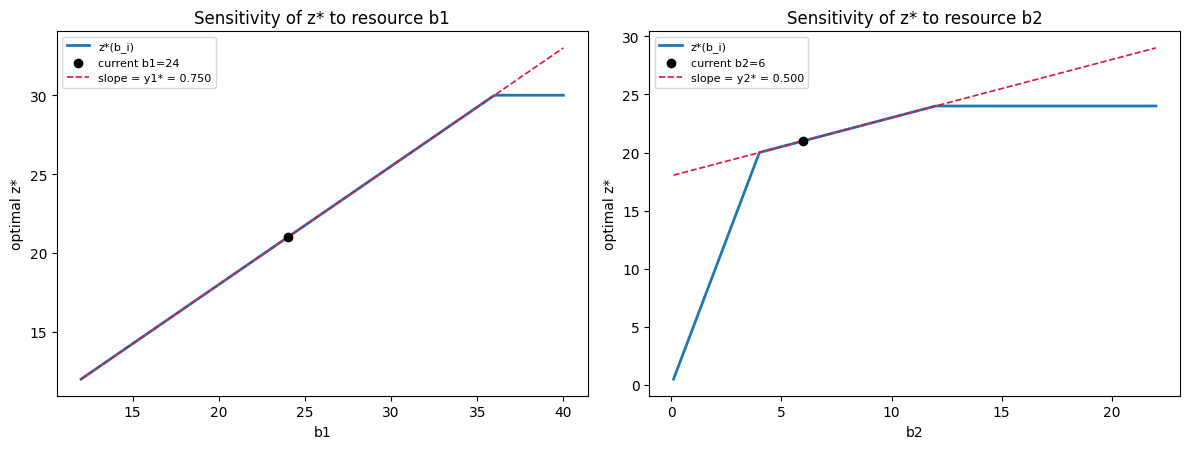

곡선은 piecewise-linear: 기울기 변화점에서 최적기저가 바뀐다(그림자가격이 꺾임).


In [5]:
# ----- z*(b_i) 곡선: 기울기=그림자가격, 기저변화에서 꺾임 -----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for i, ax in enumerate(axes):
    grid = np.linspace(max(0.1, b[i]-12), b[i]+16, 220)
    zs = []
    for v in grid:
        bv = b.copy(); bv[i] = v; zs.append(zstar(bv))
    zs = np.array(zs)
    ax.plot(grid, zs, color='tab:blue', lw=2, label='z*(b_i)')
    ax.scatter([b[i]], [z_star], color='black', zorder=6, label=f'current b{i+1}={b[i]:.0f}')
    # 현재점에서의 접선(기울기 = shadow price)
    tl = z_star + y_star[i]*(grid - b[i])
    ax.plot(grid, tl, '--', color='crimson', lw=1.2,
            label=f'slope = y{i+1}* = {y_star[i]:.3f}')
    ax.set_xlabel(f'b{i+1}'); ax.set_ylabel('optimal z*')
    ax.set_title(f'Sensitivity of z* to resource b{i+1}')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("곡선은 piecewise-linear: 기울기 변화점에서 최적기저가 바뀐다(그림자가격이 꺾임).")

## 4. 결과 해석

1. **강쌍대성**: 원문제 최적값 $z^\star=21$ 과 쌍대 최적값 $w^\star=21$ 이 정확히 일치(쌍대간격 $\sim10^{-13}$). LP가 유계 최적해를 가지므로 두 문제의 최적값이 같다는 정리가 그대로 확인된다.
2. **상보여유성**: 두 자원 제약 모두 slack $\approx0$(active)이고 그림자가격 $y^\star>0$ 이다 — slack$\times y^\star\approx0$ 이 성립. 만약 어떤 제약에 여유가 있었다면 그 그림자가격은 0이 됐을 것이다.
3. **그림자가격 = 한계가치**: 쌍대해 $y^\star$ 가 중심차분으로 구한 $\partial z^\star/\partial b_i$ 와 $10^{-6}$ 수준으로 일치한다. 즉 자원 $b_1$ 을 1단위 늘리면 이익이 약 $y_1^\star$ 만큼, $b_2$ 는 $y_2^\star$ 만큼 증가 — **희소 자원의 가격**이다.
4. **piecewise-linear 민감도**: $z^\star(b_i)$ 곡선은 직선들의 이어붙임이고, 현재점에서의 기울기가 그림자가격이다. 기울기가 꺾이는 지점은 **최적기저가 바뀌는** 경계 — 이 범위(allowable range) 안에서만 그림자가격이 유효하다.
5. **세 문제의 통합**: Problem 1의 라그랑지 승수 $\lambda$, Problem 2의 KKT 승수 $\mu$, 그리고 여기의 쌍대변수 $y$ 는 **모두 같은 그림자가격** 개념이다 — 제약을 완화할 때 목적값이 변하는 비율.

> **결론**: LP의 쌍대변수는 강쌍대성·상보여유성을 통해 자원의 그림자가격($\partial z^\star/\partial b$)으로 해석되며, 수치 민감도 분석이 이를 정확히 재현한다.

**다음 단원으로의 연결**: §13.4(이차계획·쌍대성)로 챕터 13(최적화)의 심화까지 마쳤다. 커리큘럼의 명시 로드맵(Ch 1–13)을 완주했으므로, 이후는 SQP·KKT 대규모 해법 등으로 커리큘럼을 확장해 이어갈 수 있다.